In [ ]:
# --- configuration ---------------------------------------------------
# Run this cell first. It puts src/ on the import path and points every
# read and write at the right folder, whatever your working directory.
#
# The IEEE-CIS dataset is NOT in this repository. Download
# train_transaction.csv (and train_identity.csv for the EDA cells) from
#   https://www.kaggle.com/c/ieee-fraud-detection/data
# and put them in the data/ folder, or set FRAUD_DATA_DIR.
import os, sys

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' \
       else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, 'src'))

DATA_DIR    = os.environ.get('FRAUD_DATA_DIR', os.path.join(ROOT, 'data'))
RESULTS_DIR = os.path.join(ROOT, 'results')
MODEL_DIR   = os.path.join(ROOT, 'models')
for d in (DATA_DIR, RESULTS_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

print('data   :', DATA_DIR)
print('results:', RESULTS_DIR)
print('models :', MODEL_DIR)


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import pandas as pd

trans = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))
identity = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))

print("Transaction shape:", trans.shape)
print("Identity shape:", identity.shape)
print("\nFraud ratio:")
print(trans['isFraud'].value_counts(normalize=True))
print("\nFirst few columns:", trans.columns[:10].tolist())

Transaction shape: (590540, 394)
Identity shape: (144233, 41)

Fraud ratio:
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

First few columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5']


In [2]:
import pandas as pd

trans = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))

# Candidate entity columns for nodes
candidates = ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2',
              'P_emaildomain', 'R_emaildomain', 'ProductCD']

print("Total transactions:", len(trans))
print("-" * 50)
for col in candidates:
    n_unique = trans[col].nunique()
    pct_missing = trans[col].isna().mean() * 100
    print(f"{col:16} | unique: {n_unique:>6} | missing: {pct_missing:5.1f}%")

# Time range
print("-" * 50)
print("TransactionDT min:", trans['TransactionDT'].min())
print("TransactionDT max:", trans['TransactionDT'].max())

Total transactions: 590540
--------------------------------------------------
card1            | unique:  13553 | missing:   0.0%
card2            | unique:    500 | missing:   1.5%
card3            | unique:    114 | missing:   0.3%
card5            | unique:    119 | missing:   0.7%
addr1            | unique:    332 | missing:  11.1%
addr2            | unique:     74 | missing:  11.1%
P_emaildomain    | unique:     59 | missing:  16.0%
R_emaildomain    | unique:     60 | missing:  76.8%
ProductCD        | unique:      5 | missing:   0.0%
--------------------------------------------------
TransactionDT min: 86400
TransactionDT max: 15811131


In [1]:
import pandas as pd
import numpy as np
import torch

# --- 1. Load only the columns we need ---
cols = ['TransactionID', 'isFraud', 'TransactionDT', 'card1', 'addr1']
df = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'),
                 usecols=cols)

# --- 2. An edge needs BOTH endpoints, so drop rows missing card1 or addr1 ---
before = len(df)
df = df.dropna(subset=['card1', 'addr1']).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows missing card1/addr1. Remaining: {len(df)}")

# --- 3. Sort by time (temporal models require chronological order) ---
df = df.sort_values('TransactionDT').reset_index(drop=True)

# --- 4. Map entities to contiguous node IDs ---
# Cards get IDs 0 .. (num_cards-1)
card_ids = {v: i for i, v in enumerate(df['card1'].unique())}
num_cards = len(card_ids)

# Addresses get IDs that START AFTER the cards, so the two never collide
addr_ids = {v: i + num_cards for i, v in enumerate(df['addr1'].unique())}
num_addr = len(addr_ids)

df['card_node'] = df['card1'].map(card_ids)
df['addr_node'] = df['addr1'].map(addr_ids)

# --- 5. Build the temporal graph tensors ---
src = torch.tensor(df['card_node'].values, dtype=torch.long)   # from card
dst = torch.tensor(df['addr_node'].values, dtype=torch.long)   # to address
edge_index = torch.stack([src, dst], dim=0)                    # shape [2, num_edges]
edge_time  = torch.tensor(df['TransactionDT'].values, dtype=torch.float)
edge_label = torch.tensor(df['isFraud'].values, dtype=torch.long)

total_nodes = num_cards + num_addr

# --- 6. Report ---
print("-" * 50)
print(f"Card nodes:    {num_cards}")
print(f"Address nodes: {num_addr}")
print(f"Total nodes:   {total_nodes}")
print(f"Total edges (transactions): {edge_index.shape[1]}")
print(f"edge_index shape: {edge_index.shape}")
print(f"Fraud edges: {edge_label.sum().item()} "
      f"({edge_label.float().mean().item()*100:.2f}%)")
print(f"Time range: {edge_time.min().item():.0f} → {edge_time.max().item():.0f}")

Dropped 65706 rows missing card1/addr1. Remaining: 524834
--------------------------------------------------
Card nodes:    12066
Address nodes: 332
Total nodes:   12398
Total edges (transactions): 524834
edge_index shape: torch.Size([2, 524834])
Fraud edges: 12922 (2.46%)
Time range: 86400 → 15811131


In [3]:
#Day 3 always run
import pandas as pd, numpy as np, torch
from sklearn.preprocessing import StandardScaler

PATH = os.path.join(DATA_DIR, 'train_transaction.csv')

# --- Edge features: transaction-level columns ---
edge_feat_cols = ['TransactionAmt', 'ProductCD', 'card4', 'card6'] + [f'C{i}' for i in range(1, 15)]
cols = ['TransactionID','isFraud','TransactionDT','card1','addr1'] + edge_feat_cols

df = pd.read_csv(PATH, usecols=cols)
df = df.dropna(subset=['card1','addr1']).sort_values('TransactionDT').reset_index(drop=True)

# --- Node IDs (same offset logic as Day 2) ---
card_ids = {v:i for i,v in enumerate(df['card1'].unique())}
num_cards = len(card_ids)
addr_ids = {v:i+num_cards for i,v in enumerate(df['addr1'].unique())}
num_nodes = num_cards + len(addr_ids)

src = torch.tensor(df['card1'].map(card_ids).values, dtype=torch.long)
dst = torch.tensor(df['addr1'].map(addr_ids).values, dtype=torch.long)
edge_index = torch.stack([src, dst], dim=0)
edge_time  = torch.tensor(df['TransactionDT'].values, dtype=torch.float)
edge_label = torch.tensor(df['isFraud'].values, dtype=torch.long)

# --- Build edge features ---
X = df[edge_feat_cols].copy()
X['TransactionAmt'] = np.log1p(X['TransactionAmt'])          # amounts are heavily skewed
X = pd.get_dummies(X, columns=['ProductCD','card4','card6'], dummy_na=True)
X = X.fillna(-1)                                             # C-cols: -1 flags missing

edge_feature_names = X.columns.tolist() 
# --- Chronological split points (70 / 15 / 15) ---
n = len(df)
i_tr, i_va = int(n*0.70), int(n*0.85)
train_mask = torch.zeros(n, dtype=torch.bool); train_mask[:i_tr] = True
val_mask   = torch.zeros(n, dtype=torch.bool); val_mask[i_tr:i_va] = True
test_mask  = torch.zeros(n, dtype=torch.bool); test_mask[i_va:] = True

# --- Scale using TRAIN ONLY (critical: prevents leakage) ---
scaler = StandardScaler().fit(X.iloc[:i_tr])
edge_attr = torch.tensor(scaler.transform(X).astype(np.float32))

# --- Report ---
print(f"Nodes: {num_nodes} | Edges: {n} | Edge feature dim: {edge_attr.shape[1]}")
print("-"*55)
for name, m in [('Train',train_mask), ('Val',val_mask), ('Test',test_mask)]:
    lab = edge_label[m]
    t = edge_time[m]
    print(f"{name:5} | edges: {m.sum():>6} | fraud: {lab.sum():>5} "
          f"({lab.float().mean()*100:5.2f}%) | time: {t.min():.0f} → {t.max():.0f}")

# --- Class weight for imbalance (our locked decision: weighted loss, no SMOTE) ---
tr = edge_label[train_mask]
pos_weight = (tr==0).sum().item() / (tr==1).sum().item()
print("-"*55)
print(f"pos_weight for weighted loss: {pos_weight:.2f}")

Nodes: 12398 | Edges: 524834 | Edge feature dim: 31
-------------------------------------------------------
Train | edges: 367383 | fraud:  9244 ( 2.52%) | time: 86400 → 10471402
Val   | edges:  78725 | fraud:  1882 ( 2.39%) | time: 10471443 → 13181139
Test  | edges:  78726 | fraud:  1796 ( 2.28%) | time: 13181148 → 15811131
-------------------------------------------------------
pos_weight for weighted loss: 38.74


In [2]:
train_nodes = set(edge_index[:, train_mask].flatten().tolist())
test_nodes  = set(edge_index[:, test_mask].flatten().tolist())
unseen = test_nodes - train_nodes

test_edge_src = edge_index[0, test_mask]
test_edge_dst = edge_index[1, test_mask]
unseen_t = torch.tensor(list(unseen)) if unseen else torch.tensor([], dtype=torch.long)
cold = torch.isin(test_edge_src, unseen_t) | torch.isin(test_edge_dst, unseen_t)

print(f"Nodes in train: {len(train_nodes)}")
print(f"Nodes in test:  {len(test_nodes)}")
print(f"Test nodes NEVER seen in train: {len(unseen)}")
print(f"Test edges touching an unseen node: {cold.sum().item()} ({cold.float().mean()*100:.2f}%)")
if cold.sum() > 0:
    print(f"Fraud rate among cold-start edges: {edge_label[test_mask][cold].float().mean()*100:.2f}%")

Nodes in train: 11311
Nodes in test:  5796
Test nodes NEVER seen in train: 631
Test edges touching an unseen node: 959 (1.22%)
Fraud rate among cold-start edges: 2.92%


In [8]:
from tgat_model import TGAT, NeighborFinder
import time

device = torch.device('cuda')
nf = NeighborFinder(edge_index, edge_time, num_nodes)

# keep edge features resident on the GPU — avoids a CPU->GPU copy every hop
edge_attr_gpu = edge_attr.to(device)

model = TGAT(num_nodes, edge_attr.shape[1], n_layers=2, n_heads=2).to(device)
idx = torch.where(train_mask)[0][:512]

for kk in [20, [10, 20], [5, 20]]:
    for _ in range(2):   # warm-up
        model(edge_index[0][idx], edge_index[1][idx], edge_time[idx],
              edge_attr_gpu[idx], nf, edge_attr_gpu, k=kk)
    torch.cuda.synchronize(); t0 = time.time()
    for _ in range(3):
        out = model(edge_index[0][idx], edge_index[1][idx], edge_time[idx],
                    edge_attr_gpu[idx], nf, edge_attr_gpu, k=kk)
    torch.cuda.synchronize()
    per = (time.time() - t0) / 3
    epoch_min = per * (367383 / 512) / 60
    print(f"k={str(kk):9} | {per:.3f}s/batch | ~{epoch_min:.1f} min/epoch (fwd only)")

k=20        | 0.058s/batch | ~0.7 min/epoch (fwd only)
k=[10, 20]  | 0.082s/batch | ~1.0 min/epoch (fwd only)
k=[5, 20]   | 0.021s/batch | ~0.3 min/epoch (fwd only)


In [9]:
from train import train_one, run_seeds

edge_attr = edge_attr.to('cuda')  # keep features on GPU

res, model, test_probs = train_one(
    edge_index, edge_time, edge_attr, edge_label,
    train_mask, val_mask, test_mask, num_nodes,
    pos_weight=38.74, k=20, epochs=25, batch_size=512,
    patience=5, seed=0, device='cuda', verbose=True)

print("\nTEST:", res['test'])

  ep  1 | loss 1.0727 | val PR-AUC 0.0947 | val ROC 0.7660 | val F1 0.1889
  ep  2 | loss 0.8849 | val PR-AUC 0.1193 | val ROC 0.7783 | val F1 0.1989
  ep  3 | loss 0.8076 | val PR-AUC 0.1477 | val ROC 0.7835 | val F1 0.2238
  ep  4 | loss 0.7427 | val PR-AUC 0.1653 | val ROC 0.7922 | val F1 0.2361
  ep  5 | loss 0.6765 | val PR-AUC 0.1864 | val ROC 0.7915 | val F1 0.2492
  ep  6 | loss 0.6108 | val PR-AUC 0.1822 | val ROC 0.7981 | val F1 0.2451
  ep  7 | loss 0.5479 | val PR-AUC 0.1885 | val ROC 0.7880 | val F1 0.2498
  ep  8 | loss 0.4993 | val PR-AUC 0.1745 | val ROC 0.7689 | val F1 0.2339
  ep  9 | loss 0.4602 | val PR-AUC 0.1939 | val ROC 0.7833 | val F1 0.2603
  ep 10 | loss 0.4310 | val PR-AUC 0.1899 | val ROC 0.7711 | val F1 0.2505
  ep 11 | loss 0.4022 | val PR-AUC 0.2048 | val ROC 0.7670 | val F1 0.2459
  ep 12 | loss 0.3950 | val PR-AUC 0.1969 | val ROC 0.7763 | val F1 0.2612
  ep 13 | loss 0.3683 | val PR-AUC 0.2253 | val ROC 0.7916 | val F1 0.2962
  ep 14 | loss 0.3563 | v

In [3]:
from train import train_one, run_seeds
edge_attr = edge_attr.to('cuda')   # matches what cell 7 does

In [5]:
rows = run_seeds(
    seeds=(0,1,2,3,4),
    edge_index=edge_index, edge_time=edge_time, edge_attr=edge_attr,
    edge_label=edge_label, train_mask=train_mask, val_mask=val_mask,
    test_mask=test_mask, num_nodes=num_nodes,
    pos_weight=38.74, k=20, epochs=25, batch_size=512,
    patience=5, device='cuda')


=== seed 0 ===
  ep  1 | loss 1.0727 | val PR-AUC 0.0947 | val ROC 0.7660 | val F1 0.1889
  ep  2 | loss 0.8849 | val PR-AUC 0.1193 | val ROC 0.7783 | val F1 0.1989
  ep  3 | loss 0.8076 | val PR-AUC 0.1477 | val ROC 0.7835 | val F1 0.2238
  ep  4 | loss 0.7427 | val PR-AUC 0.1653 | val ROC 0.7922 | val F1 0.2361
  ep  5 | loss 0.6765 | val PR-AUC 0.1864 | val ROC 0.7915 | val F1 0.2492
  ep  6 | loss 0.6108 | val PR-AUC 0.1822 | val ROC 0.7981 | val F1 0.2451
  ep  7 | loss 0.5479 | val PR-AUC 0.1885 | val ROC 0.7880 | val F1 0.2498
  ep  8 | loss 0.4993 | val PR-AUC 0.1745 | val ROC 0.7689 | val F1 0.2339
  ep  9 | loss 0.4602 | val PR-AUC 0.1939 | val ROC 0.7833 | val F1 0.2603
  ep 10 | loss 0.4310 | val PR-AUC 0.1899 | val ROC 0.7711 | val F1 0.2505
  ep 11 | loss 0.4022 | val PR-AUC 0.2048 | val ROC 0.7670 | val F1 0.2459
  ep 12 | loss 0.3950 | val PR-AUC 0.1969 | val ROC 0.7763 | val F1 0.2612
  ep 13 | loss 0.3683 | val PR-AUC 0.2253 | val ROC 0.7916 | val F1 0.2962
  ep 14 |

In [14]:
import json
json.dump(rows, open(os.path.join(RESULTS_DIR, 'tgat_seed_results.json'),'w'),
          indent=2, default=str)
print("saved")

saved


In [15]:
import importlib.util
print("xgboost installed:", importlib.util.find_spec("xgboost") is not None)

xgboost installed: True


In [16]:
from baseline_xgb import load_complete_case, run_xgb, _matched_features, _rich_features

PATH = os.path.join(DATA_DIR, 'train_transaction.csv')
df = load_complete_case(PATH)
print(f"complete-case rows: {len(df)} | test fraud: {df[df._split=='test']['isFraud'].mean()*100:.2f}%\n")

print("XGB-matched (same 31 features as TGAT, NO graph):")
m_matched, _ = run_xgb(df, _matched_features, 'matched', pos_weight=38.74)

print("\nXGB-rich (fuller tabular features):")
m_rich, _ = run_xgb(df, _rich_features, 'rich', pos_weight=38.74)

complete-case rows: 524834 | test fraud: 2.28%

XGB-matched (same 31 features as TGAT, NO graph):
  [matched] seed 0: PR-AUC 0.2070 | ROC 0.7647 | F1 0.2427
  [matched] seed 1: PR-AUC 0.2102 | ROC 0.7681 | F1 0.2472
  [matched] seed 2: PR-AUC 0.2116 | ROC 0.7736 | F1 0.2488
  [matched] seed 3: PR-AUC 0.2081 | ROC 0.7692 | F1 0.2542
  [matched] seed 4: PR-AUC 0.2057 | ROC 0.7731 | F1 0.2419
  [matched] MEAN: PR-AUC 0.2085±0.0021 | ROC 0.7697 | F1 0.2470

XGB-rich (fuller tabular features):
  [rich] seed 0: PR-AUC 0.2471 | ROC 0.8505 | F1 0.2809
  [rich] seed 1: PR-AUC 0.2475 | ROC 0.8473 | F1 0.2721
  [rich] seed 2: PR-AUC 0.2431 | ROC 0.8492 | F1 0.2704
  [rich] seed 3: PR-AUC 0.2449 | ROC 0.8490 | F1 0.2688
  [rich] seed 4: PR-AUC 0.2353 | ROC 0.8459 | F1 0.2622
  [rich] MEAN: PR-AUC 0.2436±0.0044 | ROC 0.8483 | F1 0.2709


In [18]:
import json
json.dump({'xgb_matched': m_matched, 'xgb_rich': m_rich},
          open(os.path.join(RESULTS_DIR, 'xgb_baselines.json'),'w'),
          indent=2, default=str)
print("saved")

saved


In [3]:
from baseline_mlp import run_mlp

# edge_attr may be on GPU from earlier; MLP handles device internally
X_np = edge_attr.detach().cpu().numpy()
y_np = edge_label.detach().cpu().numpy()

print("MLP (same 31 features, no graph):")
m_mlp, _ = run_mlp(X_np, y_np, train_mask, val_mask, test_mask,
                   pos_weight=38.74, device='cuda')

MLP (same 31 features, no graph):
  [MLP] seed 0: PR-AUC 0.1882 | ROC 0.7697 | F1 0.1904
  [MLP] seed 1: PR-AUC 0.2062 | ROC 0.7803 | F1 0.2407
  [MLP] seed 2: PR-AUC 0.2111 | ROC 0.7879 | F1 0.2307
  [MLP] seed 3: PR-AUC 0.2020 | ROC 0.7881 | F1 0.2427
  [MLP] seed 4: PR-AUC 0.2108 | ROC 0.7855 | F1 0.2221
  [MLP] MEAN: PR-AUC 0.2037±0.0084 | ROC 0.7823 | F1 0.2253


In [4]:
from train import run_seeds

edge_attr = edge_attr.to('cuda')  # ensure on GPU for the graph model

print("Static GNN (TGAT with time encoding removed):")
static_rows = run_seeds(
    seeds=(0,1,2,3,4),
    edge_index=edge_index, edge_time=edge_time, edge_attr=edge_attr,
    edge_label=edge_label, train_mask=train_mask, val_mask=val_mask,
    test_mask=test_mask, num_nodes=num_nodes,
    pos_weight=38.74, k=20, epochs=25, batch_size=512,
    patience=5, device='cuda', use_time=False)   # <- the ablation

Static GNN (TGAT with time encoding removed):

=== seed 0 ===
  ep  1 | loss 1.0733 | val PR-AUC 0.0979 | val ROC 0.7627 | val F1 0.1881
  ep  2 | loss 0.8853 | val PR-AUC 0.1215 | val ROC 0.7737 | val F1 0.2108
  ep  3 | loss 0.8017 | val PR-AUC 0.1556 | val ROC 0.7873 | val F1 0.2370
  ep  4 | loss 0.7314 | val PR-AUC 0.1550 | val ROC 0.7904 | val F1 0.2123
  ep  5 | loss 0.6547 | val PR-AUC 0.1873 | val ROC 0.7901 | val F1 0.2510
  ep  6 | loss 0.5913 | val PR-AUC 0.1887 | val ROC 0.7932 | val F1 0.2647
  ep  7 | loss 0.5328 | val PR-AUC 0.1713 | val ROC 0.7866 | val F1 0.2473
  ep  8 | loss 0.4827 | val PR-AUC 0.1915 | val ROC 0.7889 | val F1 0.2557
  ep  9 | loss 0.4419 | val PR-AUC 0.1922 | val ROC 0.7758 | val F1 0.2477
  ep 10 | loss 0.4125 | val PR-AUC 0.2179 | val ROC 0.7830 | val F1 0.2762
  ep 11 | loss 0.3902 | val PR-AUC 0.2157 | val ROC 0.7792 | val F1 0.2585
  ep 12 | loss 0.3702 | val PR-AUC 0.2164 | val ROC 0.7772 | val F1 0.2736
  ep 13 | loss 0.3554 | val PR-AUC 0.1

In [5]:
import json
json.dump({'mlp': m_mlp, 'static_gnn': static_rows},
          open(os.path.join(RESULTS_DIR, 'mlp_static_results.json'),'w'),
          indent=2, default=str)
print("saved")

saved


In [6]:
import numpy as np
# how many transactions touch each address node?
addr_counts = np.bincount(edge_index[1].numpy() - num_cards)
addr_counts = addr_counts[addr_counts > 0]
print(f"Address hub sizes — min: {addr_counts.min()}, max: {addr_counts.max()}, "
      f"mean: {addr_counts.mean():.0f}, median: {int(np.median(addr_counts))}")
print(f"Biggest hub touches {addr_counts.max()} transactions")

Address hub sizes — min: 1, max: 46335, mean: 1581, median: 3
Biggest hub touches 46335 transactions


In [7]:
card_counts = np.bincount(edge_index[0].numpy())
card_counts = card_counts[card_counts > 0]
print(f"Card hub sizes — median: {int(np.median(card_counts))}, "
      f"mean: {card_counts.mean():.0f}, max: {card_counts.max()}")

Card hub sizes — median: 4, mean: 43, max: 14926


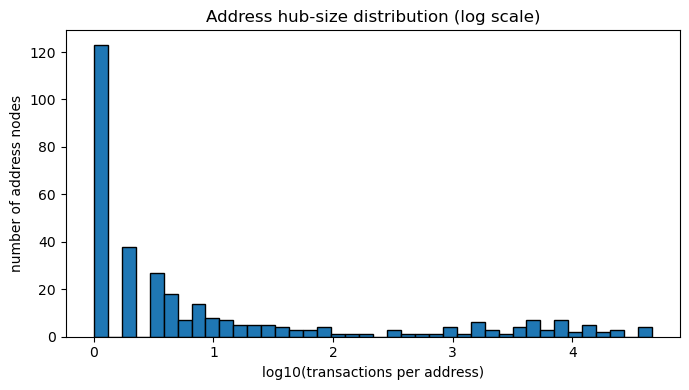

In [8]:
import matplotlib.pyplot as plt
import numpy as np
addr_counts = np.bincount(edge_index[1].numpy() - num_cards)
addr_counts = addr_counts[addr_counts > 0]

plt.figure(figsize=(7,4))
plt.hist(np.log10(addr_counts), bins=40, edgecolor='black')
plt.xlabel('log10(transactions per address)')
plt.ylabel('number of address nodes')
plt.title('Address hub-size distribution (log scale)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'addr_hub_distribution.png'), dpi=150)
plt.show()

In [9]:
import pandas as pd

PATH = os.path.join(DATA_DIR, 'train_transaction.csv')
IDPATH = os.path.join(DATA_DIR, 'train_identity.csv')

trans = pd.read_csv(PATH)
ident = pd.read_csv(IDPATH)

# merge identity onto transactions (left join keeps all transactions)
df = trans.merge(ident, on='TransactionID', how='left')
print(f"Total transactions: {len(df)}")
print(f"Transactions with identity info: {ident.shape[0]} "
      f"({ident.shape[0]/len(df)*100:.1f}%)\n")

# every candidate we might use as a node
candidates = ['card1','card2','card3','card5','addr1','addr2',
              'P_emaildomain','R_emaildomain',
              'DeviceInfo','DeviceType','id_30','id_31','id_33']

print(f"{'column':16} | {'unique':>7} | {'missing':>8} | {'txns/node':>10}")
print("-"*55)
for col in candidates:
    if col not in df.columns:
        print(f"{col:16} | NOT FOUND")
        continue
    n_unique = df[col].nunique()
    pct_missing = df[col].isna().mean()*100
    # average transactions per node value (only over non-missing)
    per_node = (df[col].notna().sum() / n_unique) if n_unique else 0
    print(f"{col:16} | {n_unique:>7} | {pct_missing:>7.1f}% | {per_node:>10.0f}")

Total transactions: 590540
Transactions with identity info: 144233 (24.4%)

column           |  unique |  missing |  txns/node
-------------------------------------------------------
card1            |   13553 |     0.0% |         44
card2            |     500 |     1.5% |       1163
card3            |     114 |     0.3% |       5166
card5            |     119 |     0.7% |       4927
addr1            |     332 |    11.1% |       1581
addr2            |      74 |    11.1% |       7092
P_emaildomain    |      59 |    16.0% |       8408
R_emaildomain    |      60 |    76.8% |       2288
DeviceInfo       |    1786 |    79.9% |         66
DeviceType       |       2 |    76.2% |      70405
id_30            |      75 |    86.9% |       1034
id_31            |     130 |    76.2% |       1079
id_33            |     260 |    87.6% |        282


In [10]:
df_nodes = pd.DataFrame({
    'column': candidates,
    'unique': [df[c].nunique() if c in df.columns else 0 for c in candidates],
    'missing_%': [round(df[c].isna().mean()*100,1) if c in df.columns else None for c in candidates],
    'txns_per_node': [round(df[c].notna().sum()/df[c].nunique()) if c in df.columns and df[c].nunique()>0 else 0 for c in candidates]
}).sort_values('txns_per_node')
df_nodes.to_csv(os.path.join(RESULTS_DIR, 'node_candidate_analysis.csv'), index=False)
print(df_nodes.to_string(index=False))

       column  unique  missing_%  txns_per_node
        card1   13553        0.0             44
   DeviceInfo    1786       79.9             66
        id_33     260       87.6            282
        id_30      75       86.9           1034
        id_31     130       76.2           1079
        card2     500        1.5           1163
        addr1     332       11.1           1581
R_emaildomain      60       76.8           2288
        card5     119        0.7           4927
        card3     114        0.3           5166
        addr2      74       11.1           7092
P_emaildomain      59       16.0           8408
   DeviceType       2       76.2          70405


In [ ]:
!pip install shap

In [4]:
import sys
!{sys.executable} -m pip install "numpy<2" --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.8/15.5 MB 10.1 MB/s eta 0:00:02
   ---------- ----------------------------- 3.9/15.5 MB 9.4 MB/s eta 0:00:02
   -------------- ------------------------- 5.8/15.5 MB 9.3 MB/s eta 0:00:02
   ------------------- -------------------- 7.6/15.5 MB 9.4 MB/s eta 0:00:01
   ------------------------- -------------- 9.7/15.5 MB 9.4 MB/s eta 0:00:01
   ----------------------------- ---------- 11.5/15.5 MB 9.4 MB/s eta 0:00:01
   ----------------------------------- ---- 13.6/15.5 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------  15.5/15.5 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 9.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [1]:
import numpy as np
print("numpy:", np.__version__)   # want 1.26.x or similar, NOT 2.x
import pandas as pd
print("pandas ok")
import torch
print("torch ok")
import shap
print("shap ok")
print("ALL GOOD")

numpy: 1.26.4
pandas ok
torch ok
shap ok
ALL GOOD


In [4]:
from tgat_model import TGAT, NeighborFinder
from train import train_one
from xai_shap_tgat import explain_tgat_shap, make_background, top_features
from xai_gnnexplainer import explain_edge_tgat, print_explanation
import torch, time

device = torch.device('cuda')
nf = NeighborFinder(edge_index, edge_time, num_nodes)
edge_attr = edge_attr.to('cuda')
print("ready")

ready


In [5]:
print(len(edge_feature_names), "feature names")

31 feature names


In [6]:
_, model, _ = train_one(edge_index, edge_time, edge_attr, edge_label,
    train_mask, val_mask, test_mask, num_nodes, pos_weight=38.74,
    k=20, epochs=25, device='cuda', verbose=True)

  ep  1 | loss 1.0727 | val PR-AUC 0.0947 | val ROC 0.7660 | val F1 0.1889
  ep  2 | loss 0.8849 | val PR-AUC 0.1193 | val ROC 0.7783 | val F1 0.1989
  ep  3 | loss 0.8076 | val PR-AUC 0.1477 | val ROC 0.7835 | val F1 0.2238
  ep  4 | loss 0.7427 | val PR-AUC 0.1653 | val ROC 0.7922 | val F1 0.2361
  ep  5 | loss 0.6765 | val PR-AUC 0.1864 | val ROC 0.7915 | val F1 0.2492
  ep  6 | loss 0.6108 | val PR-AUC 0.1822 | val ROC 0.7981 | val F1 0.2451
  ep  7 | loss 0.5479 | val PR-AUC 0.1885 | val ROC 0.7880 | val F1 0.2498
  ep  8 | loss 0.4993 | val PR-AUC 0.1745 | val ROC 0.7689 | val F1 0.2339
  ep  9 | loss 0.4602 | val PR-AUC 0.1939 | val ROC 0.7833 | val F1 0.2603
  ep 10 | loss 0.4310 | val PR-AUC 0.1899 | val ROC 0.7711 | val F1 0.2505
  ep 11 | loss 0.4022 | val PR-AUC 0.2048 | val ROC 0.7670 | val F1 0.2459
  ep 12 | loss 0.3950 | val PR-AUC 0.1969 | val ROC 0.7763 | val F1 0.2612
  ep 13 | loss 0.3683 | val PR-AUC 0.2253 | val ROC 0.7916 | val F1 0.2962
  ep 14 | loss 0.3563 | v

In [7]:
torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'tgat_trained.pt'))
print("saved — never training again")

saved — never training again


In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import torch
print(torch.cuda.is_available())

True


In [4]:
from tgat_model import TGAT, NeighborFinder
from xai_shap_tgat import explain_tgat_shap, make_background, top_features
from xai_gnnexplainer import explain_edge_tgat, print_explanation
import time, numpy as np

device = torch.device('cuda')
nf = NeighborFinder(edge_index, edge_time, num_nodes)
edge_attr = edge_attr.to('cuda')

model = TGAT(num_nodes, edge_attr.shape[1], node_dim=64, time_dim=32,
             n_layers=2, n_heads=2).to('cuda')
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'tgat_trained.pt')))
model.eval()
print("model loaded — fresh GPU")

model loaded — fresh GPU


<notebook>:8: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  edge_attr = edge_attr.to('cuda')
<notebook>:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don'

In [5]:
test_idx = torch.where(test_mask)[0]
preds = []
with torch.no_grad():
    for i in range(0, len(test_idx), 2000):
        b = test_idx[i:i+2000]
        logit = model(edge_index[0][b], edge_index[1][b],
                      edge_time[b], edge_attr[b], nf, edge_attr, k=20)
        preds.append(torch.sigmoid(logit).cpu())
        torch.cuda.empty_cache()
pred = torch.cat(preds)
fraud_like = test_idx[pred.argsort(descending=True)[:10]]
print("picked", len(fraud_like))

picked 10


In [5]:
bg = make_background(edge_attr, train_mask, n=30)

t0 = time.time()
shap_res = explain_tgat_shap(model, fraud_like[:1], edge_index, edge_time, edge_attr,
        nf, edge_feature_names, bg, k=20, nsamples=100, device='cuda')
print(f"one edge took {time.time()-t0:.1f}s")
top_features(shap_res, k=15)

one edge took 1.0s
rank  feature                       mean|SHAP|
   1  ProductCD_W                      0.41534
   2  ProductCD_R                      0.09074
   3  C13                              0.07033
   4  C14                              0.05722
   5  card4_visa                       0.05425
   6  TransactionAmt                   0.05041
   7  C5                               0.03875
   8  C11                              0.03555
   9  C4                               0.02996
  10  C8                               0.02323
  11  C6                               0.00000
  12  C12                              0.00000
  13  C3                               0.00000
  14  C9                               0.00000
  15  C2                               0.00000


In [6]:
shap_res = explain_tgat_shap(model, fraud_like, edge_index, edge_time, edge_attr,
        nf, edge_feature_names, bg, k=20, nsamples=100, device='cuda')
print("SHAP on TGAT — global feature importance:")
top_features(shap_res, k=15)

SHAP on TGAT — global feature importance:
rank  feature                       mean|SHAP|
   1  ProductCD_W                      0.22297
   2  ProductCD_H                      0.10607
   3  C13                              0.06997
   4  TransactionAmt                   0.06320
   5  C14                              0.04867
   6  ProductCD_R                      0.04205
   7  C5                               0.02542
   8  C8                               0.02291
   9  C6                               0.02125
  10  C2                               0.02089
  11  C1                               0.01895
  12  C11                              0.01865
  13  card4_visa                       0.01485
  14  card6_debit                      0.01409
  15  C10                              0.01184


In [8]:
import json
json.dump({'tgat_shap_global': shap_res['global_importance']},
          open(os.path.join(RESULTS_DIR, 'tgat_shap.json'),'w'),
          indent=2, default=str)
print("saved")

saved


In [7]:
for ti in fraud_like[:5]:
    ti = int(ti)
    res = explain_edge_tgat(model, int(edge_index[0][ti]), int(edge_index[1][ti]),
            float(edge_time[ti]), edge_attr[ti], nf, edge_attr, k=20,
            epochs=200, device='cuda')
    print("="*60)
    print_explanation(res, feature_names=edge_feature_names, k=6)

target predicted FRAUD (logit +9.827)

most influential CARD-side prior transactions (node, edge_id, dt, mask):
  node  12092 | edge  455290 | dt 693 | mask 0.997
  node  12110 | edge  455283 | dt 1032 | mask 0.997
  node  12090 | edge  455298 | dt 199 | mask 0.997
  node  12104 | edge  450647 | dt 114447 | mask 0.003
  node  12079 | edge  447556 | dt 204107 | mask 0.003
  node  12101 | edge  447085 | dt 211782 | mask 0.003
most influential ADDRESS-side prior transactions:
  node    157 | edge  455096 | dt 8367 | mask 0.997
  node    252 | edge  455110 | dt 8010 | mask 0.997
  node   5798 | edge  455095 | dt 8372 | mask 0.997
  node    451 | edge  455208 | dt 4432 | mask 0.997
  node    177 | edge  455098 | dt 8364 | mask 0.997
  node   4671 | edge  455178 | dt 5766 | mask 0.003
most influential TARGET-EDGE features:
  card6_credit             mask 0.997
  TransactionAmt           mask 0.997
  card4_visa               mask 0.997
  C5                       mask 0.996
  C14              

In [9]:
import json
out = []
for ti in fraud_like[:5]:
    ti = int(ti)
    res = explain_edge_tgat(model, int(edge_index[0][ti]), int(edge_index[1][ti]),
            float(edge_time[ti]), edge_attr[ti], nf, edge_attr, k=20, epochs=200, device='cuda')
    out.append({'edge': ti, 'logit': res['base_logit'],
                'card_side': res['src_neighbours'][:6],
                'addr_side': res['dst_neighbours'][:6],
                'feature_mask': res['feature_mask'].tolist()})
json.dump(out, open(os.path.join(RESULTS_DIR, 'gnnexplainer_results.json'),'w'),
          indent=2, default=str)
print("saved")

saved


In [6]:
print(type(model), len(fraud_like))

<class 'tgat_model.TGAT'> 10


In [11]:
import torch, numpy as np

def faithfulness_check(model, ti, nf, edge_index, edge_time, edge_attr, k=20, device='cuda'):
    src = int(edge_index[0][ti]); dst = int(edge_index[1][ti]); t = float(edge_time[ti])
    ef = edge_attr[ti]

    # 1) original prediction
    with torch.no_grad():
        base_logit = model(torch.tensor([src]), torch.tensor([dst]),
                           torch.tensor([t]), ef.unsqueeze(0), nf, edge_attr, k=k).item()
    base_p = torch.sigmoid(torch.tensor(base_logit)).item()

    # 2) get the explanation to know which neighbours are "important"
    res = explain_edge_tgat(model, src, dst, t, ef, nf, edge_attr,
                            k=k, epochs=200, device=device)

    # neighbour arrays + all-ones baseline masks
    nbr_s, eid_s, dt_s, m_s = model.outer_neighbours(src, t, nf, k)
    nbr_d, eid_d, dt_d, m_d = model.outer_neighbours(dst, t, nf, k)
    Ks, Kd = len(nbr_s), len(nbr_d)
    keep_s = torch.tensor(m_s, dtype=torch.float32, device=device)
    keep_d = torch.tensor(m_d, dtype=torch.float32, device=device)
    feat_keep = torch.ones(ef.shape[-1], device=device)

    # rebuild the per-slot mask values GNNExplainer assigned, to find top slots
    def slot_scores(neigh_list, nbr_arr):
        # neigh_list is sorted (node,eid,dt,mask); map back to slot importance
        score = np.zeros(len(nbr_arr))
        for node, eid_, dt_, msk in neigh_list:
            for j in range(len(nbr_arr)):
                if int(nbr_arr[j]) == node:
                    score[j] = max(score[j], msk)
        return score

    sc_s = slot_scores(res['src_neighbours'], nbr_s)
    sc_d = slot_scores(res['dst_neighbours'], nbr_d)

    results = {'edge': int(ti), 'base_p': base_p}
    for topn in [3, 5]:
        ks_ = keep_s.clone(); kd_ = keep_d.clone()
        # zero out the top-N most important valid neighbours on each side
        for j in np.argsort(sc_s)[::-1][:topn]:
            if m_s[j]: ks_[j] = 0.0
        for j in np.argsort(sc_d)[::-1][:topn]:
            if m_d[j]: kd_[j] = 0.0
        with torch.no_grad():
            logit = model.explain_forward(src, dst, t, nf, edge_attr, k,
                                          ks_, kd_, ef.to(device), feat_keep)
        p_removed = torch.sigmoid(logit).item()
        results[f'p_remove_top{topn}'] = p_removed
        results[f'drop_top{topn}'] = base_p - p_removed
    return results

# run on your fraud edges
print(f"{'edge':>8} {'base_p':>8} {'remove3':>8} {'drop3':>7} {'remove5':>8} {'drop5':>7}")
faith = []
for ti in fraud_like[:5]:
    r = faithfulness_check(model, int(ti), nf, edge_index, edge_time, edge_attr, k=20)
    faith.append(r)
    print(f"{r['edge']:>8} {r['base_p']:>8.3f} {r['p_remove_top3']:>8.3f} "
          f"{r['drop_top3']:>7.3f} {r['p_remove_top5']:>8.3f} {r['drop_top5']:>7.3f}")

    edge   base_p  remove3   drop3  remove5   drop5
  455303    1.000    1.000   0.000    1.000   0.000
  449122    1.000    1.000   0.000    1.000   0.000
  482799    1.000    1.000  -0.000    1.000  -0.000
  468854    1.000    1.000  -0.000    1.000  -0.000
  449879    1.000    1.000   0.000    1.000   0.000


In [12]:
import numpy as np, torch

def stability_check(model, ti, nf, edge_index, edge_time, edge_attr, k=20,
                    runs=8, topn=5, device='cuda'):
    src = int(edge_index[0][ti]); dst = int(edge_index[1][ti]); t = float(edge_time[ti])
    ef = edge_attr[ti]
    nbr_s, _, _, m_s = model.outer_neighbours(src, t, nf, k)

    top_sets = []
    feat_ranks = []
    for r in range(runs):
        torch.manual_seed(r)   # different init each run
        res = explain_edge_tgat(model, src, dst, t, ef, nf, edge_attr,
                                k=k, epochs=200, device=device)
        # top-N card-side neighbour NODES this run
        top_nodes = [row[0] for row in res['src_neighbours'][:topn]]
        top_sets.append(set(top_nodes))
        # feature ranking this run
        feat_ranks.append(np.argsort(res['feature_mask'])[::-1][:topn].tolist())

    # Jaccard overlap between every pair of runs (1.0 = identical selection)
    jac = []
    for a in range(runs):
        for b in range(a+1, runs):
            inter = len(top_sets[a] & top_sets[b])
            union = len(top_sets[a] | top_sets[b])
            jac.append(inter/union if union else 1.0)

    return {'edge': int(ti), 'runs': runs,
            'mean_jaccard': float(np.mean(jac)),
            'min_jaccard': float(np.min(jac)),
            'top_sets': [sorted(s) for s in top_sets]}

# run on one edge first
s = stability_check(model, int(fraud_like[0]), nf, edge_index, edge_time, edge_attr,
                    k=20, runs=8, topn=5)
print(f"edge {s['edge']}: mean Jaccard {s['mean_jaccard']:.3f} "
      f"(min {s['min_jaccard']:.3f}) over {s['runs']} runs")
print("selected top-5 neighbour sets per run:")
for i, st in enumerate(s['top_sets']):
    print(f"  run {i}: {st}")

edge 455303: mean Jaccard 1.000 (min 1.000) over 8 runs
selected top-5 neighbour sets per run:
  run 0: [12079, 12090, 12092, 12104, 12110]
  run 1: [12079, 12090, 12092, 12104, 12110]
  run 2: [12079, 12090, 12092, 12104, 12110]
  run 3: [12079, 12090, 12092, 12104, 12110]
  run 4: [12079, 12090, 12092, 12104, 12110]
  run 5: [12079, 12090, 12092, 12104, 12110]
  run 6: [12079, 12090, 12092, 12104, 12110]
  run 7: [12079, 12090, 12092, 12104, 12110]


In [13]:
import json
json.dump({'faithfulness': faith, 'stability_edge0': s},
          open(os.path.join(RESULTS_DIR, 'xai_validation.json'),'w'),
          indent=2, default=str)
print("saved")

saved


In [14]:
import torch, numpy as np

def faithfulness_check(model, ti, nf, edge_index, edge_time, edge_attr, k=20, device='cuda'):
    src=int(edge_index[0][ti]); dst=int(edge_index[1][ti]); t=float(edge_time[ti])
    ef=edge_attr[ti]
    with torch.no_grad():
        base_logit=model(torch.tensor([src]),torch.tensor([dst]),torch.tensor([t]),
                         ef.unsqueeze(0),nf,edge_attr,k=k).item()
    res=explain_edge_tgat(model,src,dst,t,ef,nf,edge_attr,k=k,epochs=200,device=device)
    nbr_s,eid_s,dt_s,m_s=model.outer_neighbours(src,t,nf,k)
    nbr_d,eid_d,dt_d,m_d=model.outer_neighbours(dst,t,nf,k)
    keep_s=torch.tensor(m_s,dtype=torch.float32,device=device)
    keep_d=torch.tensor(m_d,dtype=torch.float32,device=device)
    fk=torch.ones(ef.shape[-1],device=device)

    def slot_scores(neigh_list, eid_arr):          # map importance by EDGE id (unique)
        mp={int(e):msk for _,e,_,msk in neigh_list}
        return np.array([mp.get(int(eid_arr[j]),0.0) for j in range(len(eid_arr))])
    sc_s=slot_scores(res['src_neighbours'],eid_s); sc_d=slot_scores(res['dst_neighbours'],eid_d)

    def logit_with(ws,wd):
        with torch.no_grad():
            return model.explain_forward(src,dst,t,nf,edge_attr,k,ws,wd,ef.to(device),fk).item()

    out={'edge':int(ti),'base':base_logit}
    out['allkeep']=logit_with(keep_s.clone(),keep_d.clone())            # sanity ≈ base
    out['no_neighbours']=logit_with(torch.zeros_like(keep_s),torch.zeros_like(keep_d))  # graph ceiling
    for topn in [3,5]:
        ks_=keep_s.clone(); kd_=keep_d.clone()
        for j in np.argsort(sc_s)[::-1][:topn]:
            if m_s[j]: ks_[j]=0.0
        for j in np.argsort(sc_d)[::-1][:topn]:
            if m_d[j]: kd_[j]=0.0
        out[f'remove_top{topn}']=logit_with(ks_,kd_)
    return out

print(f"{'edge':>8} {'base':>7} {'allkeep':>8} {'no_nbr':>8} {'rm_top3':>8} {'rm_top5':>8}")
for ti in fraud_like[:5]:
    r=faithfulness_check(model,int(ti),nf,edge_index,edge_time,edge_attr,k=20)
    print(f"{r['edge']:>8} {r['base']:>7.2f} {r['allkeep']:>8.2f} {r['no_neighbours']:>8.2f} "
          f"{r['remove_top3']:>8.2f} {r['remove_top5']:>8.2f}")

    edge    base  allkeep   no_nbr  rm_top3  rm_top5
  455303    9.83     9.83     8.38     8.94     8.72
  449122    8.82     8.82     9.91     8.54     8.02
  482799    8.68     8.68    11.22     8.89     9.10
  468854    8.54     8.54     4.01     8.51     7.96
  449879    8.51     8.51     9.75     8.26     7.96


In [ ]:
import json
faith_out = []
for ti in fraud_like[:5]:
    r = faithfulness_check(model, int(ti), nf, edge_index, edge_time, edge_attr, k=20)
    faith_out.append(r)
json.dump({'faithfulness': faith_out, 'stability_jaccard': 1.000},
          open(os.path.join(RESULTS_DIR, 'xai_validation.json'),'w'),
          indent=2, default=str)
print("saved")

In [7]:
def comprehensiveness(model, ti, nf, edge_index, edge_time, edge_attr, k=20,
                      topn=5, trials=15, device='cuda'):
    src=int(edge_index[0][ti]); dst=int(edge_index[1][ti]); t=float(edge_time[ti]); ef=edge_attr[ti]
    fk=torch.ones(ef.shape[-1],device=device)
    with torch.no_grad():
        base=model(torch.tensor([src]),torch.tensor([dst]),torch.tensor([t]),
                   ef.unsqueeze(0),nf,edge_attr,k=k).item()
    res=explain_edge_tgat(model,src,dst,t,ef,nf,edge_attr,k=k,epochs=200,device=device)
    nbr_s,eid_s,dt_s,m_s=model.outer_neighbours(src,t,nf,k)
    nbr_d,eid_d,dt_d,m_d=model.outer_neighbours(dst,t,nf,k)
    keep_s=torch.tensor(m_s,dtype=torch.float32,device=device)
    keep_d=torch.tensor(m_d,dtype=torch.float32,device=device)
    def logit_with(ws,wd):
        with torch.no_grad():
            return model.explain_forward(src,dst,t,nf,edge_attr,k,ws,wd,ef.to(device),fk).item()
    def sc(nl,ea):
        mp={int(e):msk for _,e,_,msk in nl}; return np.array([mp.get(int(ea[j]),0.) for j in range(len(ea))])
    scs=sc(res['src_neighbours'],eid_s); scd=sc(res['dst_neighbours'],eid_d)
    ks=keep_s.clone(); kd=keep_d.clone()
    for j in np.argsort(scs)[::-1][:topn]:
        if m_s[j]: ks[j]=0
    for j in np.argsort(scd)[::-1][:topn]:
        if m_d[j]: kd[j]=0
    expl=abs(base-logit_with(ks,kd))
    vs=np.where(m_s)[0]; vd=np.where(m_d)[0]; rand=[]
    for _ in range(trials):
        ks=keep_s.clone(); kd=keep_d.clone()
        for j in np.random.choice(vs,min(topn,len(vs)),replace=False): ks[j]=0
        for j in np.random.choice(vd,min(topn,len(vd)),replace=False): kd[j]=0
        rand.append(abs(base-logit_with(ks,kd)))
    return {'edge':int(ti),'explainer_drop':expl,'random_drop':float(np.mean(rand))}

print(f"{'edge':>8} {'GNNExpl':>8} {'random':>8} {'ratio':>7}")
for ti in fraud_like[:5]:
    r=comprehensiveness(model,int(ti),nf,edge_index,edge_time,edge_attr,k=20)
    ratio=r['explainer_drop']/r['random_drop'] if r['random_drop']>1e-6 else float('nan')
    print(f"{r['edge']:>8} {r['explainer_drop']:>8.3f} {r['random_drop']:>8.3f} {ratio:>7.2f}")

    edge  GNNExpl   random   ratio
  455303    1.108    0.480    2.31
  449122    0.804    0.143    5.62
  482799    0.423    0.385    1.10
  468854    0.576    0.311    1.85
  449879    0.552    0.212    2.60
